<a href="https://colab.research.google.com/github/Cado87/Fruit-project/blob/main/Detection/YOLO/Roboflow_fruits/Finetune_YOLO26_roboflow_fruit_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="h4cT0fR7NYJQWUIdF1pd")
project = rf.workspace("fruitsdetection").project("fruits-by-yolo")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fruits-by-YOLO-1 in yolov8:: 100%|██████████| 5960/5960 [00:00<00:00, 9278.40it/s] 


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 83.9 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

# Load a COCO-pretrained YOLO26n model
model = YOLO("yolo26n.pt")

# Train the model on the COCO8 example dataset for 100 epochs
results = model.train(data="/content/Fruits-by-YOLO-1/data.yaml", epochs=150, imgsz=640, patience=20)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fruits-by-YOLO-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

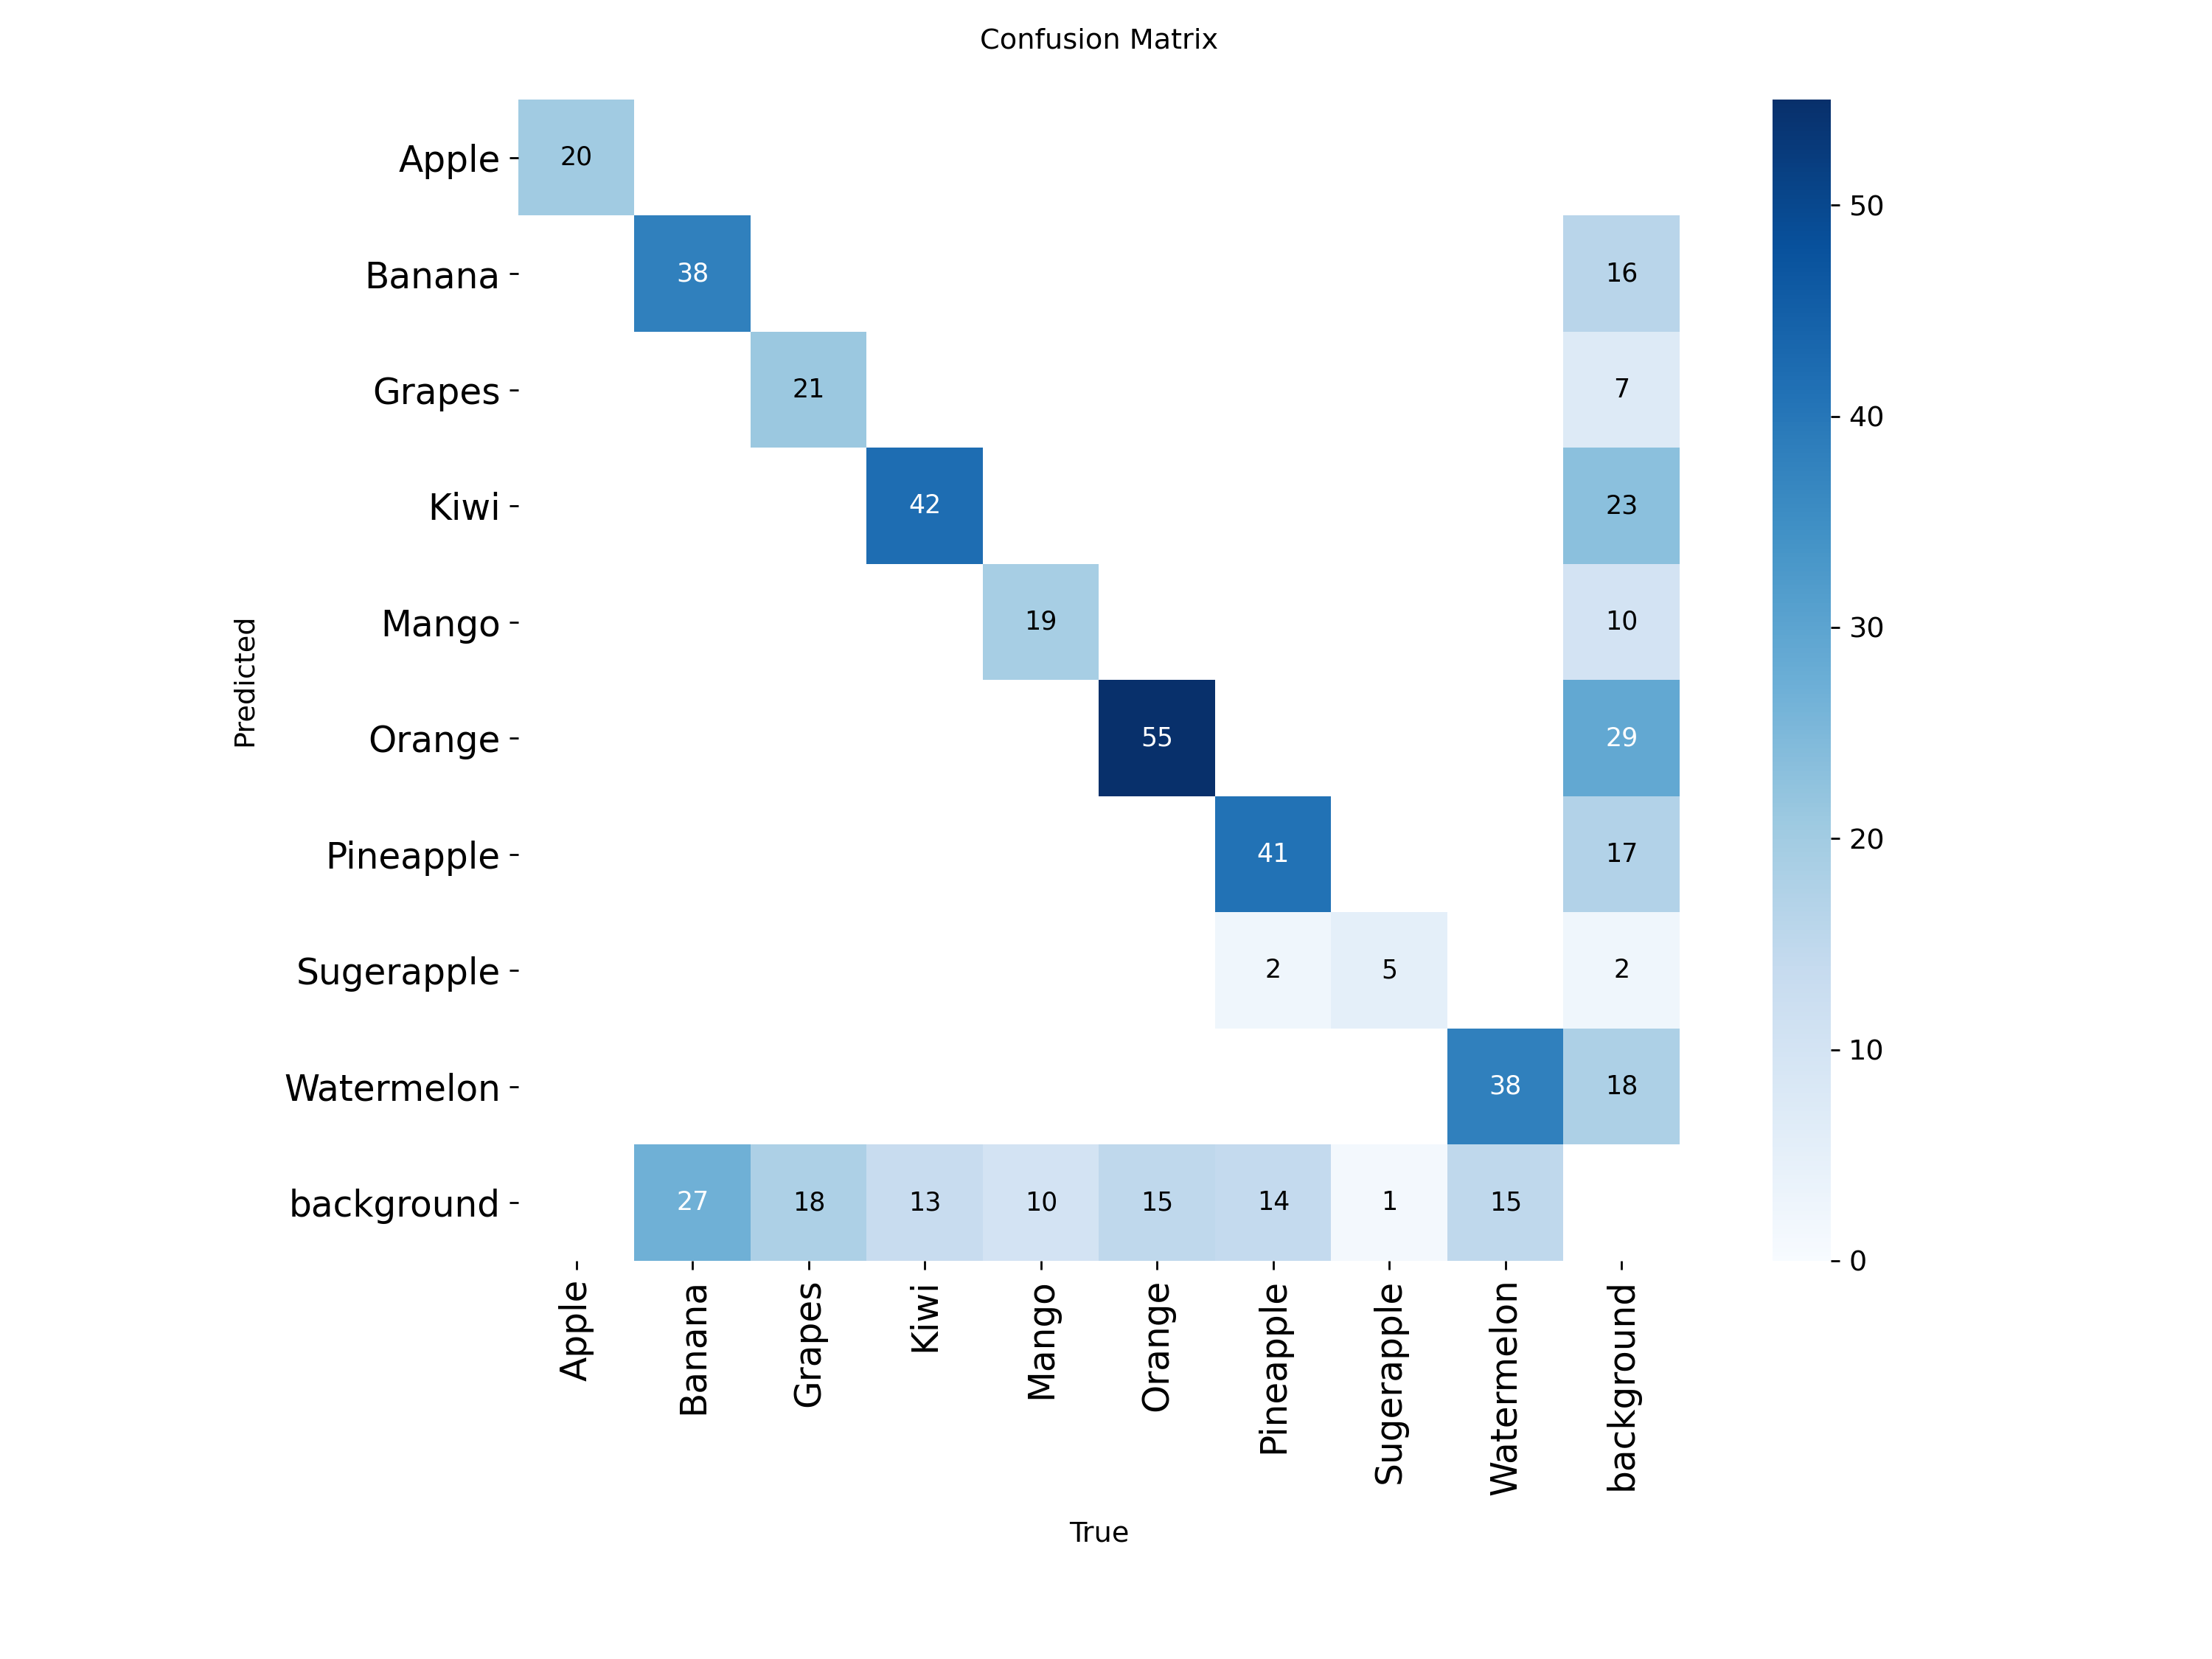

In [4]:
from IPython.display import Image
Image(filename='/content/runs/detect/train/confusion_matrix.png')

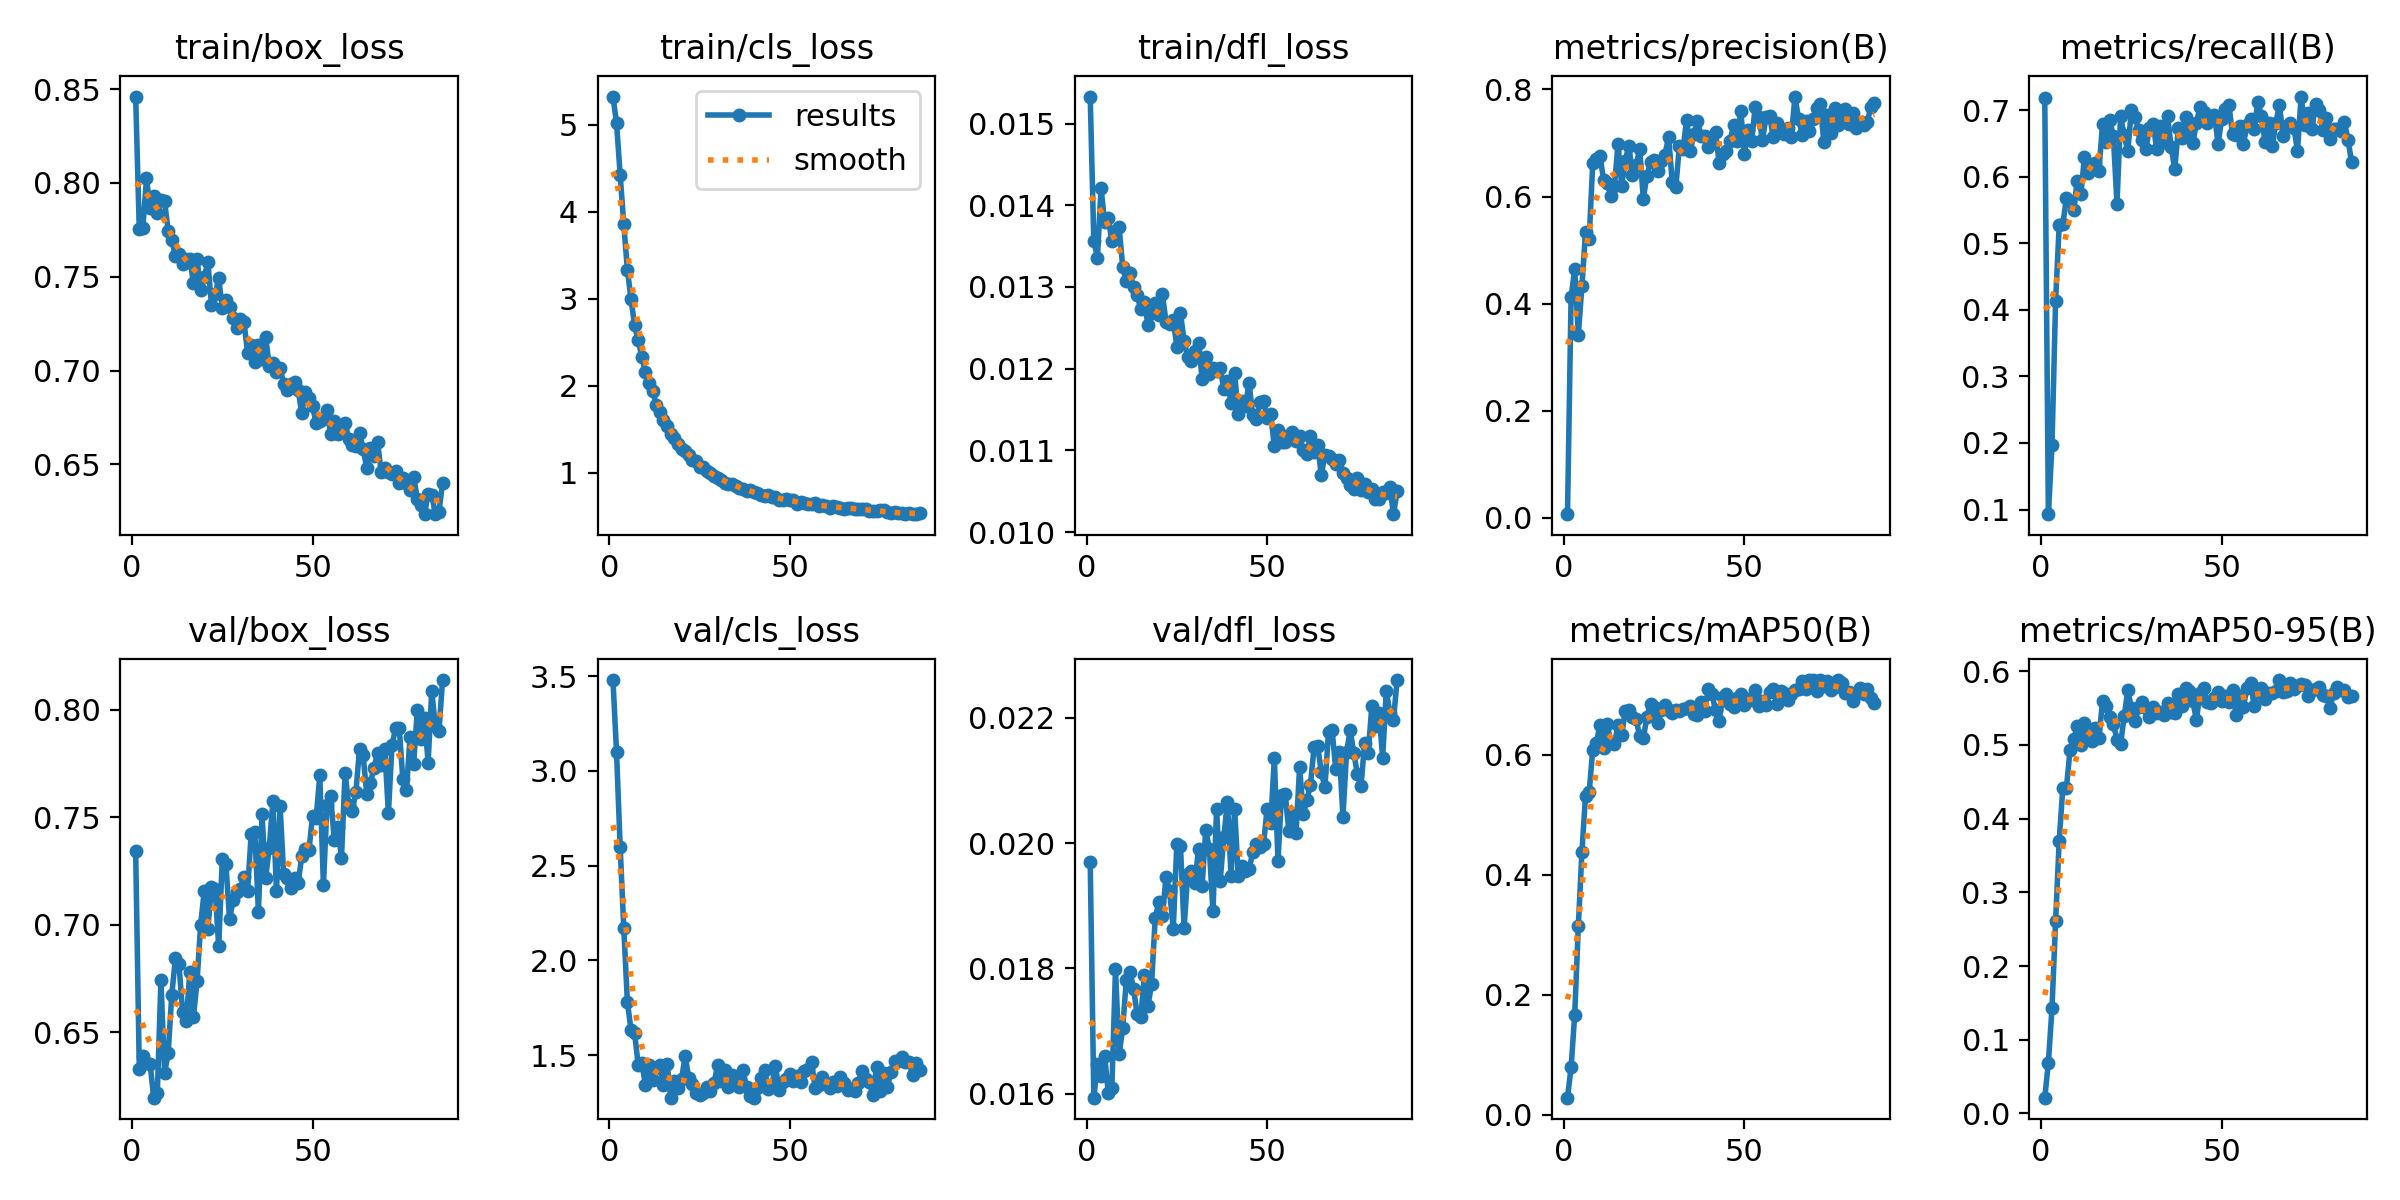

In [5]:
Image(filename='/content/runs/detect/train/results.png')

In [6]:
# Load a model
model = YOLO("/content/runs/detect/train/weights/best.pt")  # load a custom model

# Validate the model
metrics = model.val()  # no arguments needed, dataset and settings remembered
print('mAP50-95:', metrics.box.map)  # map50-95
print('mAP50: ',metrics.box.map50)  # map50
print('mAP75: ', metrics.box.map75)  # map75
print('mAP50-95 per category', metrics.box.maps)

Ultralytics 8.4.5 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO26n summary (fused): 122 layers, 2,376,591 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 999.7±124.9 MB/s, size: 34.3 KB)
val: Scanning /content/Fruits-by-YOLO-1/valid/labels.cache... 187 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 187/187 78.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 390, len(boxes) = 394. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 5.5it/s 2.2s
                   all        187        394       0.72      0.702      0.723      0.587
                 Apple         16         20      0.997          1      0.995      0.939
                Banana

In [9]:
!zip -r /content/train.zip /content/runs/detect/train
!zip -r /content/val.zip /content/runs/detect/val

  adding: content/runs/detect/train/ (stored 0%)
  adding: content/runs/detect/train/BoxPR_curve.png (deflated 10%)
  adding: content/runs/detect/train/val_batch0_pred.jpg (deflated 8%)
  adding: content/runs/detect/train/labels.jpg (deflated 27%)
  adding: content/runs/detect/train/val_batch1_labels.jpg (deflated 11%)
  adding: content/runs/detect/train/confusion_matrix.png (deflated 22%)
  adding: content/runs/detect/train/train_batch0.jpg (deflated 4%)
  adding: content/runs/detect/train/weights/ (stored 0%)
  adding: content/runs/detect/train/weights/best.pt (deflated 11%)
  adding: content/runs/detect/train/weights/last.pt (deflated 11%)
  adding: content/runs/detect/train/results.png (deflated 7%)
  adding: content/runs/detect/train/val_batch0_labels.jpg (deflated 8%)
  adding: content/runs/detect/train/train_batch1.jpg (deflated 4%)
  adding: content/runs/detect/train/train_batch2.jpg (deflated 7%)
  adding: content/runs/detect/train/args.yaml (deflated 52%)
  adding: content/ru